In [1]:
# The usual preamble
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Make the graphs a bit prettier, and bigger
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (15, 5)


C:\Users\hjbec\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Let's continue with our NYC 311 service requests example.

In [9]:
# because of mixed types we specify dtype to prevent any errors
url = "https://raw.githubusercontent.com/pgarco/GESISPython2025/refs/heads/main/data/Titanic-Dataset.csv"
titanic = pd.read_csv(url, dtype='unicode')

In [10]:
titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,NaN,S


# More Data Selection

Let's find out which age group had the best chance of survival on the Titanic

In [ ]:
# Define age bins and labels
bins = [0, 12, 18, 30, 50, 80]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

# Create a new column for age group
titanic['age_group'] = pd.cut(titanic['Age'], bins=bins, labels=labels)

In [16]:
titanic['Age'] = pd.to_numeric(titanic['Age'], errors='coerce')

In [17]:
# Define age bins and labels
bins = [0, 12, 18, 30, 50, 80]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

# Create a new column for age group
titanic['age_group'] = pd.cut(titanic['Age'], bins=bins, labels=labels)

Let's take a look at this new column next to Age

In [19]:
titanic[['Age','age_group']]

,Age,age_group
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Adult
4,35.0,Adult
...,...,...
886,27.0,Young Adult
887,19.0,Young Adult
888,NaN,NaN
889,26.0,Young Adult


Here you will notice that there is a value called NaN. 
We seem to be missing the age of some passengers!
We can fix that by either dropping these or filling them with the median age!

In [22]:
# dropping columns with no age value
titanic = titanic.dropna(subset=['Age'])

In [ ]:
#Replacing NaN values with the median age
titanic['Age'].fillna(titanic['Age'].median(), inplace=True)

Let's filter our dataframe by only survivors:

In [29]:
# First let us convert the string value to int in Survived
titanic['Survived'] = pd.to_numeric(titanic['Survived'], errors='coerce').astype('Int64')

In [30]:
# Filter the dataset to include only survivors
survivors = titanic[titanic['Survived'] == 1]

Now I have a new dataframe with the survivors, so I can calculate how many survivors are in each age group

In [31]:
# Count how many survivors are in each age group
survivors_by_age_group = survivors['age_group'].value_counts().sort_index()
print(survivors_by_age_group)

age_group
Child           40
Teen            30
Young Adult     96
Adult          102
Senior          22
Name: count, dtype: int64


Adults and Young Adults have the highest number of survivors. But of course that doesn't tell us anything about your survival chances. We need to calculate the proportion of survivors.

let's calculate your chances of survival based on your age group:

In [33]:
survival_rate = titanic.groupby('age_group')['Survived'].mean()
print(survival_rate)

age_group
Child           0.57971
Teen           0.428571
Young Adult    0.355556
Adult          0.423237
Senior          0.34375
Name: Survived, dtype: Float64


C:\Users\hjbec\AppData\Local\Temp\ipykernel_46596\1340379101.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate = titanic.groupby('age_group')['Survived'].mean()


This gives you the mean of the  column, which works because  is 1 for survivors and 0 for non-survivors — so the mean equals the proportion.

<Axes: xlabel='age_group'>

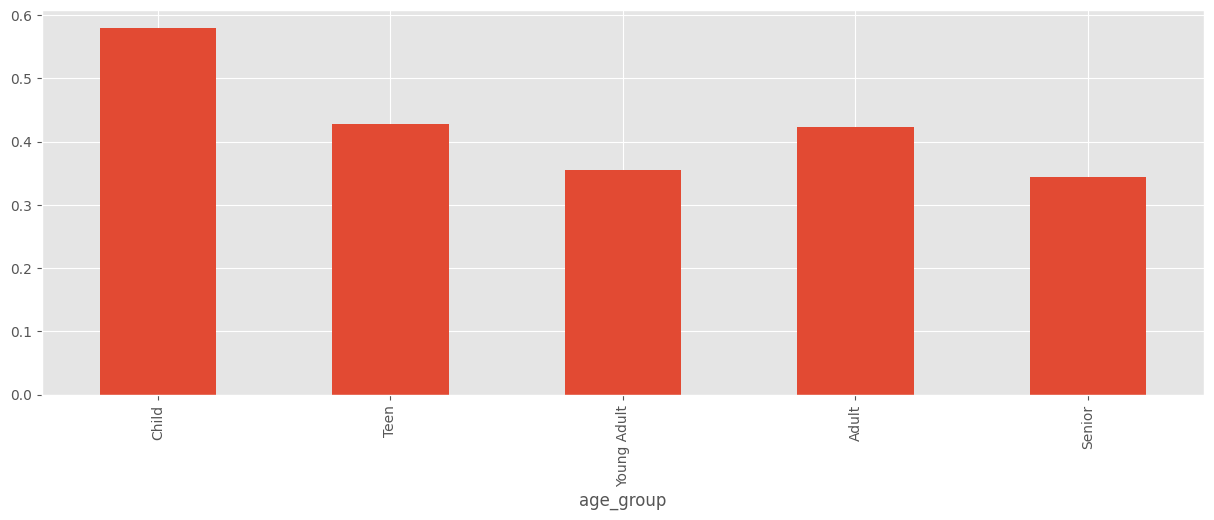

In [35]:
survival_rate.plot(kind='bar')

It looks like children were indeed prioritised in the evacuation, but not by that much. 

Another strong theory is that your cabin class was a much stronger indicator of your survival chances on the titanic. Let's test out that theory.

In [36]:
# Group by class and calculate mean survival rate
class_survival_rate = titanic.groupby('Pclass')['Survived'].mean() * 100

# Round for readability
print(class_survival_rate.round(2))

Pclass
1    65.59
2    47.98
3    23.94
Name: Survived, dtype: Float64


Just for fun, let's combine this all into one final plot. You should be able to visualise data like this by the end of the workshop:

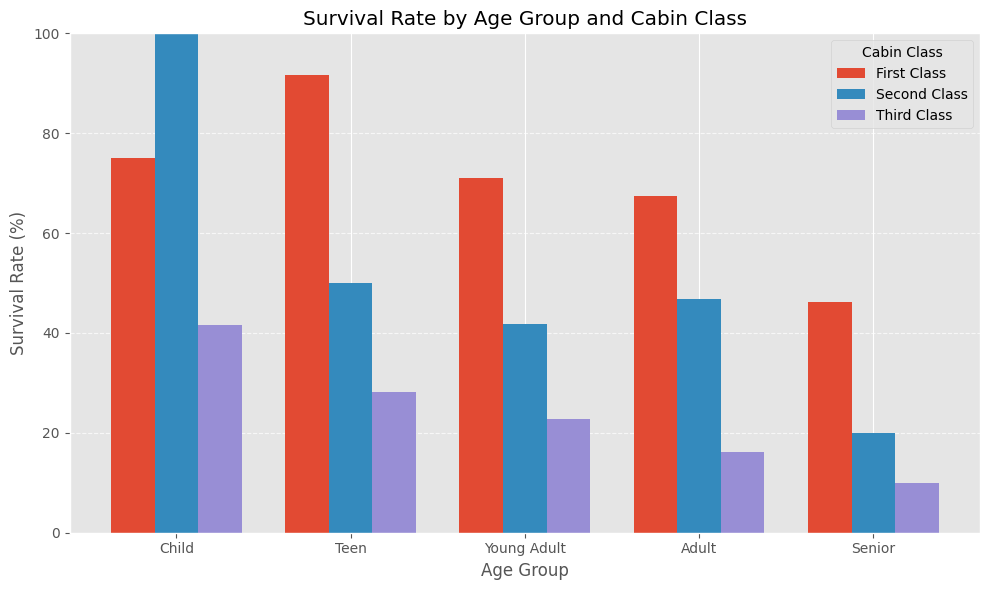

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Clean and prepare data
titanic_clean = titanic.copy() # Create a copy to avoid SettingWithCopyWarning
titanic_clean['Age'] = pd.to_numeric(titanic_clean['Age'], errors='coerce')
# Convert Pclass to numeric before mapping
titanic_clean['Pclass'] = pd.to_numeric(titanic_clean['Pclass'], errors='coerce')
titanic_clean = titanic_clean.dropna(subset=['Age', 'Pclass', 'Survived'])
titanic_clean.loc[:, 'Survived'] = pd.to_numeric(titanic_clean['Survived'], errors='coerce')
titanic_clean.loc[:, 'age_group'] = pd.cut(titanic_clean['Age'], bins=[0, 12, 18, 30, 50, 80],
                                    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
titanic_clean.loc[:, 'class_label'] = titanic_clean['Pclass'].map({1: 'First Class', 2: 'Second Class', 3: 'Third Class'})

# Step 2: Group and calculate survival rate
grouped = titanic_clean.groupby(['age_group', 'class_label'], observed=False)['Survived'].mean().unstack() * 100

# Step 3: Plot grouped bar chart
age_groups = grouped.index
class_labels = grouped.columns
x = np.arange(len(age_groups))  # the label locations
width = 0.25  # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot each class as a separate bar group
for i, cls in enumerate(class_labels):
    ax.bar(x + i*width, grouped[cls], width, label=cls)

# Formatting
ax.set_xlabel('Age Group')
ax.set_ylabel('Survival Rate (%)')
ax.set_title('Survival Rate by Age Group and Cabin Class')
ax.set_xticks(x + width*(len(class_labels)-1)/2)
ax.set_xticklabels(age_groups)
ax.set_ylim(0, 100)
ax.legend(title='Cabin Class')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

I found this interesting, and I wondered why the pattern of first class outsurviving the other classes is broken with children. So I wanted to see what happened here. So I had a look at the list, filtered for first class children and their ages. 

In [54]:
# Filter the DataFrame for First Class children
first_class_children = titanic_clean[(titanic_clean['class_label'] == 'First Class') & (titanic_clean['age_group'] == 'Child')]


In [53]:
first_class_children[['Age', 'Pclass', 'Survived', 'Name']]

,Age,Pclass,Survived,Name
297,2.00,1,0,"Allison, Miss. Helen Loraine"
305,0.92,1,1,"Allison, Master. Hudson Trevor"
445,4.00,1,1,"Dodge, Master. Washington"
802,11.00,1,1,"Carter, Master. William Thornton II"


I looked up the tragic story of Helen, why her brother Trevor survived while she didn't. But that's a story for another day.

<style>
    @font-face {
        font-family: "Computer Modern";
        src: url('http://mirrors.ctan.org/fonts/cm-unicode/fonts/otf/cmunss.otf');
    }
    div.cell{
        width:800px;
        margin-left:16% !important;
        margin-right:auto;
    }
    h1 {
        font-family: Helvetica, serif;
    }
    h4{
        margin-top:12px;
        margin-bottom: 3px;
       }
    div.text_cell_render{
        font-family: Computer Modern, "Helvetica Neue", Arial, Helvetica, Geneva, sans-serif;
        line-height: 145%;
        font-size: 130%;
        width:800px;
        margin-left:auto;
        margin-right:auto;
    }
    .CodeMirror{
            font-family: "Source Code Pro", source-code-pro,Consolas, monospace;
    }
    .text_cell_render h5 {
        font-weight: 300;
        font-size: 22pt;
        color: #4057A1;
        font-style: italic;
        margin-bottom: .5em;
        margin-top: 0.5em;
        display: block;
    }
    
    .warning{
        color: rgb( 240, 20, 20 )
        }  